#   SPRINT 1: DATA UNDERSTANDING & PREPROCESSING

##  Step 1: Data Collection & Loading

In [17]:
# Install Libraries
import pandas as pd

In [18]:
# Load Dataset
df=pd.read_csv(r'mental_tiredness_score_prediction_dataset.csv')
df.head()

,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,work_environment,noise_level_db,temperature_c,workload_score,mental_tiredness_score
0,110,14,70,196.5,65.1,7.0,136.1,1,7.84,26.75,2.05,Happy,Remote,Moderate Noise,53.8,19.8,3.3,22.17
1,122,9,66,256.4,135.2,6.5,83.9,3,7.18,17.82,1.82,Low,Remote,Noisy,38.9,18.7,4.6,25.35
2,113,4,55,387.3,54.2,10.0,176.5,5,5.52,27.78,1.92,Happy,Office,Quiet,42.0,26.4,7.9,34.36
3,113,8,45,300.3,107.1,4.8,164.7,2,8.47,3.48,1.89,Happy,Manual,Quiet,47.2,23.8,5.4,11.92
4,95,8,68,240.5,3.2,8.0,186.3,4,7.48,21.17,2.41,Happy,Manual,Moderate Noise,61.0,24.2,8.5,37.45


In [19]:
# Dataset Size and Columns
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
df.columns

Number of Rows: 15000
Number of Columns: 18


Index(['number_of_decisions_made', 'context_switch_count',
       'notifications_received', 'screen_time_min', 'deep_work_min',
       'task_complexity_avg', 'caffeine_mg', 'break_frequency', 'sleep_hours',
       'deep_sleep_pct', 'hydration_l', 'mood', 'work_type',
       'work_environment', 'noise_level_db', 'temperature_c', 'workload_score',
       'mental_tiredness_score'],
      dtype='object')

 ## Step 2: Initial Data Inspection


In [21]:
df.head(5) # First 5 Rows

,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,work_environment,noise_level_db,temperature_c,workload_score,mental_tiredness_score
0,110,14,70,196.5,65.1,7.0,136.1,1,7.84,26.75,2.05,Happy,Remote,Moderate Noise,53.8,19.8,3.3,22.17
1,122,9,66,256.4,135.2,6.5,83.9,3,7.18,17.82,1.82,Low,Remote,Noisy,38.9,18.7,4.6,25.35
2,113,4,55,387.3,54.2,10.0,176.5,5,5.52,27.78,1.92,Happy,Office,Quiet,42.0,26.4,7.9,34.36
3,113,8,45,300.3,107.1,4.8,164.7,2,8.47,3.48,1.89,Happy,Manual,Quiet,47.2,23.8,5.4,11.92
4,95,8,68,240.5,3.2,8.0,186.3,4,7.48,21.17,2.41,Happy,Manual,Moderate Noise,61.0,24.2,8.5,37.45


In [22]:
df.tail() # Last 5 Rows

,number_of_decisions_made,context_switch_count,notifications_received,screen_time_min,deep_work_min,task_complexity_avg,caffeine_mg,break_frequency,sleep_hours,deep_sleep_pct,hydration_l,mood,work_type,work_environment,noise_level_db,temperature_c,workload_score,mental_tiredness_score
14995,132,14,69,207.9,162.3,6.8,51.8,4,4.58,5.83,1.29,Low,Remote,Noisy,46.0,21.6,6.6,48.53
14996,111,11,49,365.2,69.4,7.7,67.0,1,7.39,18.18,1.65,Low,Student,Moderate Noise,42.0,26.0,6.6,50.75
14997,108,7,66,405.5,54.0,3.8,0.0,7,7.22,15.83,2.11,Low,Remote,Quiet,39.5,23.4,3.5,9.61
14998,143,8,64,402.8,18.2,3.0,0.0,5,7.89,16.72,0.38,Low,Office,Moderate Noise,54.4,27.1,6.0,32.05
14999,119,12,75,262.5,104.9,6.0,246.8,2,8.26,26.08,3.15,Neutral,Student,Quiet,27.5,22.2,2.8,8.97


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   number_of_decisions_made  15000 non-null  int64  
 1   context_switch_count      15000 non-null  int64  
 2   notifications_received    15000 non-null  int64  
 3   screen_time_min           15000 non-null  float64
 4   deep_work_min             15000 non-null  float64
 5   task_complexity_avg       15000 non-null  float64
 6   caffeine_mg               15000 non-null  float64
 7   break_frequency           15000 non-null  int64  
 8   sleep_hours               15000 non-null  float64
 9   deep_sleep_pct            15000 non-null  float64
 10  hydration_l               15000 non-null  float64
 11  mood                      15000 non-null  object 
 12  work_type                 15000 non-null  object 
 13  work_environment          15000 non-null  object 
 14  noise_

In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
number_of_decisions_made,15000.0,120.079133,10.882327,82.0,113.000,120.00,127.0000,165.00
context_switch_count,15000.0,7.982133,2.837784,0.0,6.000,8.00,10.0000,21.00
notifications_received,15000.0,64.967800,8.114420,30.0,59.000,65.00,70.0000,101.00
screen_time_min,15000.0,302.211107,136.575167,20.0,205.300,302.00,396.1000,852.20
deep_work_min,15000.0,96.698407,61.249273,0.0,50.100,94.80,138.8000,312.80
task_complexity_avg,15000.0,5.505333,1.957174,1.0,4.175,5.50,6.8000,10.00
caffeine_mg,15000.0,131.170247,79.542710,0.0,72.200,129.00,185.5000,422.90
break_frequency,15000.0,4.001733,2.017358,0.0,3.000,4.00,5.0000,13.00
sleep_hours,15000.0,6.893889,1.296186,3.0,6.010,6.90,7.7800,11.00
deep_sleep_pct,15000.0,19.017639,5.958026,0.0,15.040,18.98,23.0625,41.38


In [25]:
df.describe(include=['object'])

,mood,work_type,work_environment
count,15000,15000,15000
unique,3,4,3
top,Happy,Student,Quiet
freq,6287,5238,6042


In [26]:
# Checking Data Types
df.dtypes

number_of_decisions_made      int64
context_switch_count          int64
notifications_received        int64
screen_time_min             float64
deep_work_min               float64
task_complexity_avg         float64
caffeine_mg                 float64
break_frequency               int64
sleep_hours                 float64
deep_sleep_pct              float64
hydration_l                 float64
mood                         object
work_type                    object
work_environment             object
noise_level_db              float64
temperature_c               float64
workload_score              float64
mental_tiredness_score      float64
dtype: object

In [27]:
# Checking Missing Values
df.isnull().sum()

number_of_decisions_made    0
context_switch_count        0
notifications_received      0
screen_time_min             0
deep_work_min               0
task_complexity_avg         0
caffeine_mg                 0
break_frequency             0
sleep_hours                 0
deep_sleep_pct              0
hydration_l                 0
mood                        0
work_type                   0
work_environment            0
noise_level_db              0
temperature_c               0
workload_score              0
mental_tiredness_score      0
dtype: int64

In [28]:
# Checking Unique Values
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].unique())


mood:
['Happy' 'Low' 'Neutral']

work_type:
['Remote' 'Office' 'Manual' 'Student']

work_environment:
['Moderate Noise' 'Noisy' 'Quiet']


In [29]:
# Checking Duplicates
df.duplicated().sum()

0

## Step 3: Data Cleaning

In [31]:
# Checking Missing Values
df.isna().sum()

number_of_decisions_made    0
context_switch_count        0
notifications_received      0
screen_time_min             0
deep_work_min               0
task_complexity_avg         0
caffeine_mg                 0
break_frequency             0
sleep_hours                 0
deep_sleep_pct              0
hydration_l                 0
mood                        0
work_type                   0
work_environment            0
noise_level_db              0
temperature_c               0
workload_score              0
mental_tiredness_score      0
dtype: int64

In [32]:
# Dropping Duplicates
df=df.drop_duplicates()

## Step 4: Exploratory Data Analysis (EDA)

#### -- Univariate Analysis

In [35]:
import matplotlib.pyplot as plt

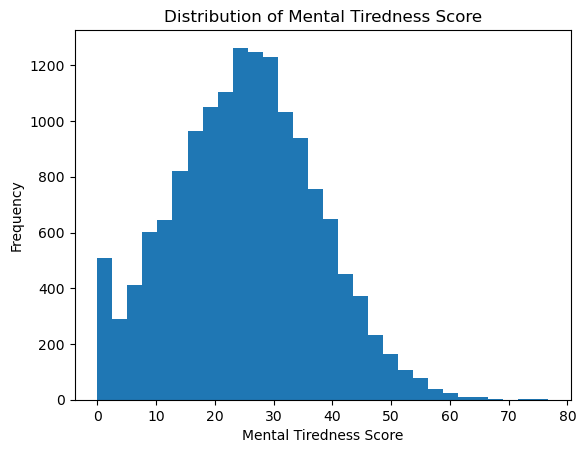

In [36]:
plt.hist(x=df['mental_tiredness_score'],bins=30)
plt.xlabel("Mental Tiredness Score")
plt.ylabel("Frequency")
plt.title("Distribution of Mental Tiredness Score")
plt.show()

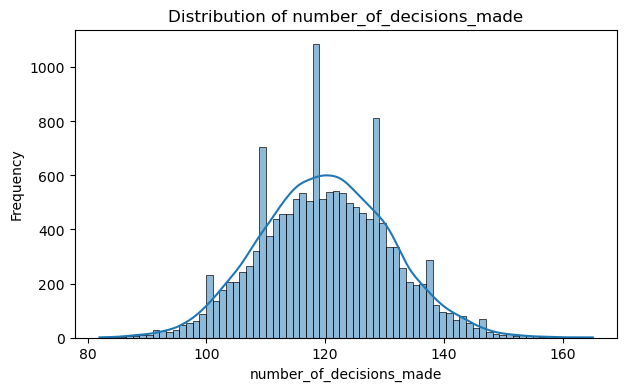

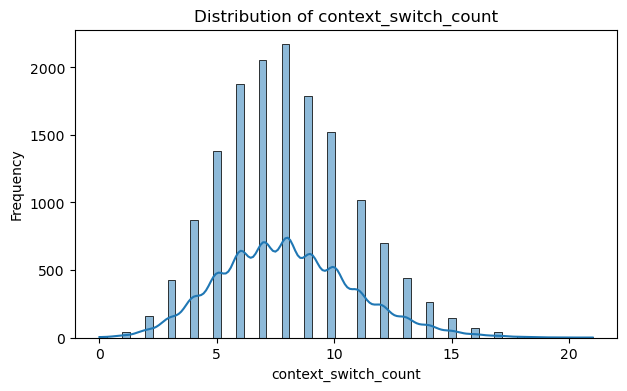

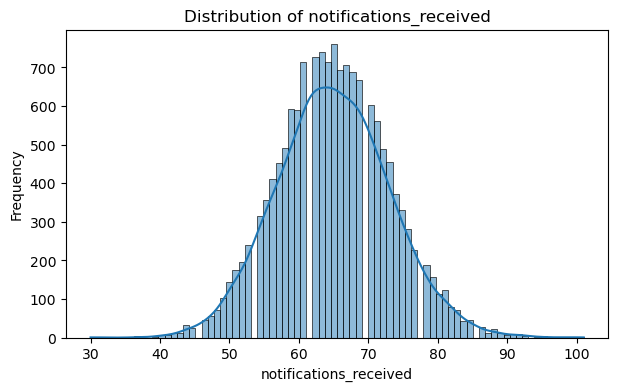

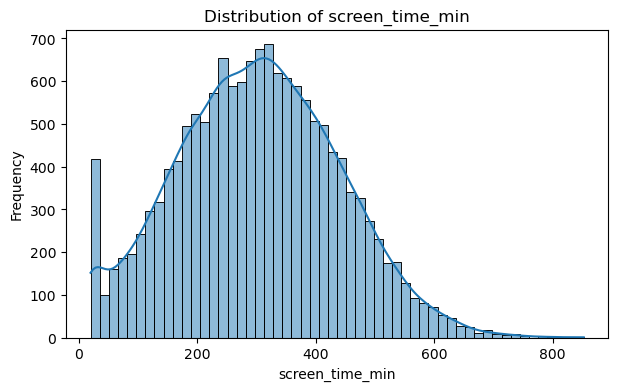

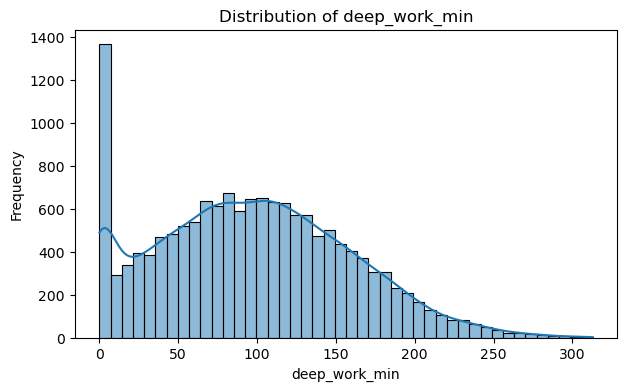

...

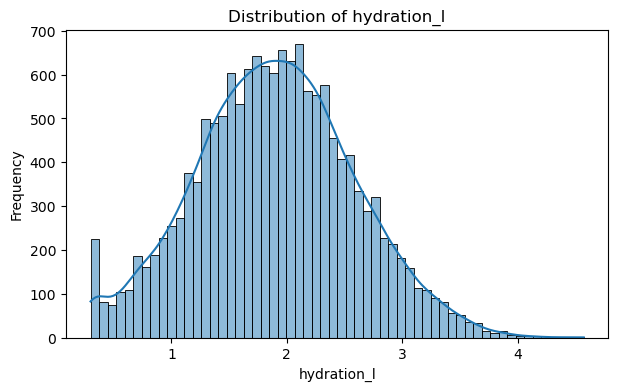

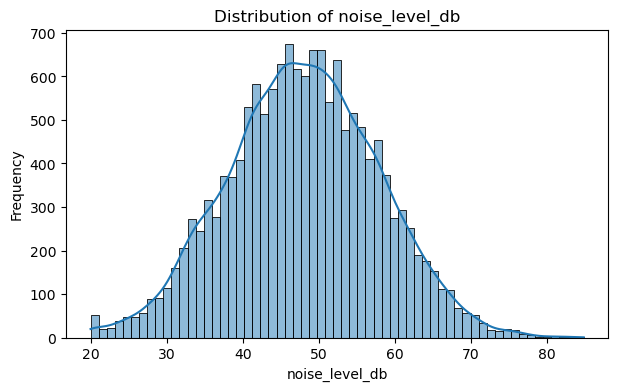

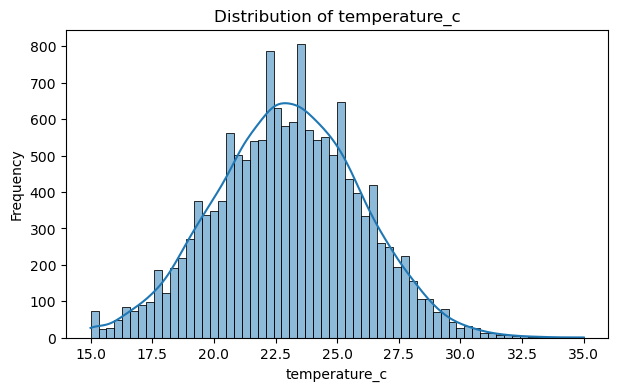

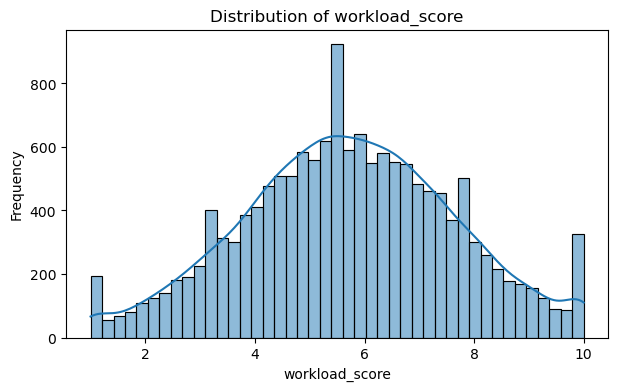

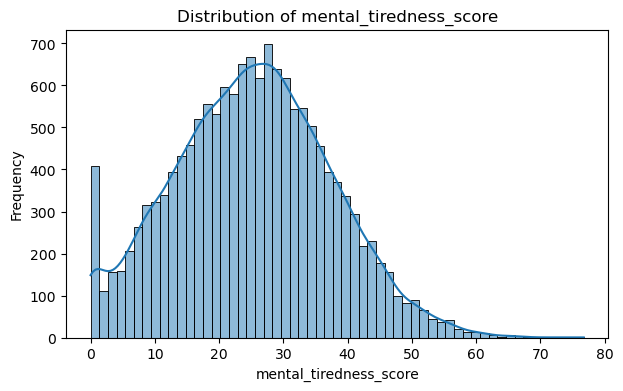

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


In [43]:
# checking skewness
skewness = df[num_cols].skew().sort_values(ascending=False)

print(skewness)

break_frequency             0.495119
context_switch_count        0.369507
deep_work_min               0.298261
caffeine_mg                 0.266219
screen_time_min             0.119071
mental_tiredness_score      0.107726
notifications_received      0.104212
number_of_decisions_made    0.063937
hydration_l                 0.061899
deep_sleep_pct              0.026630
temperature_c               0.012999
noise_level_db             -0.004253
sleep_hours                -0.014786
task_complexity_avg        -0.016845
workload_score             -0.033925
dtype: float64


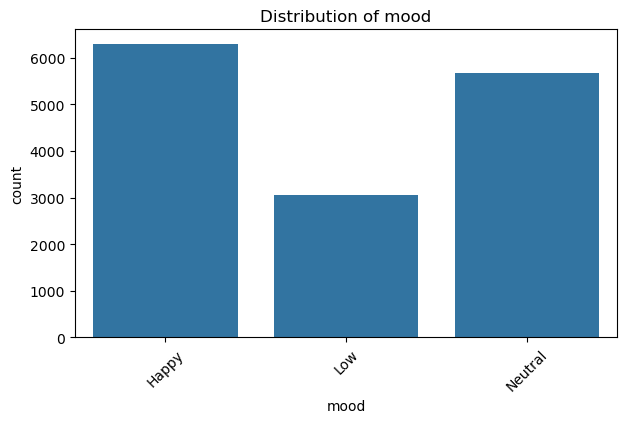

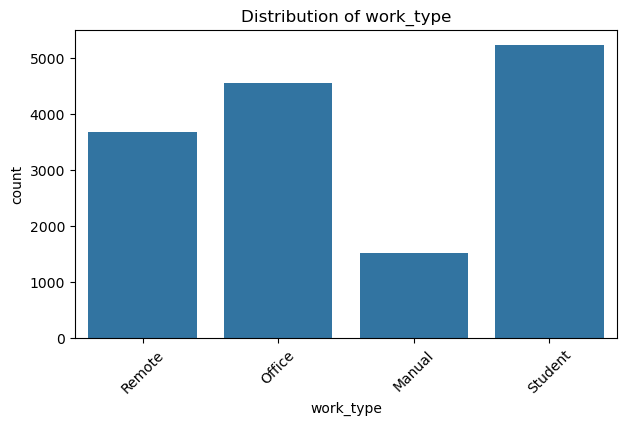

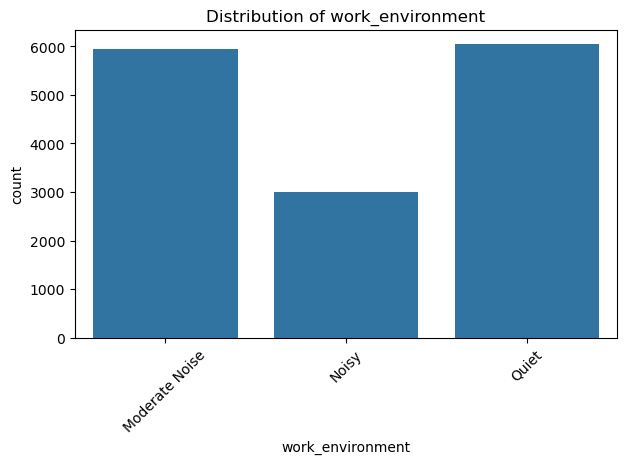

In [39]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

 #### -- Bivariate Analysis

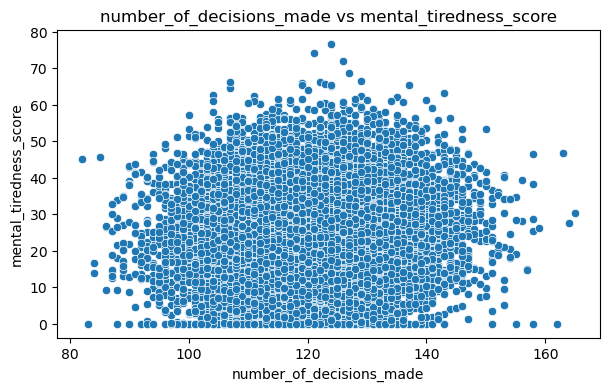

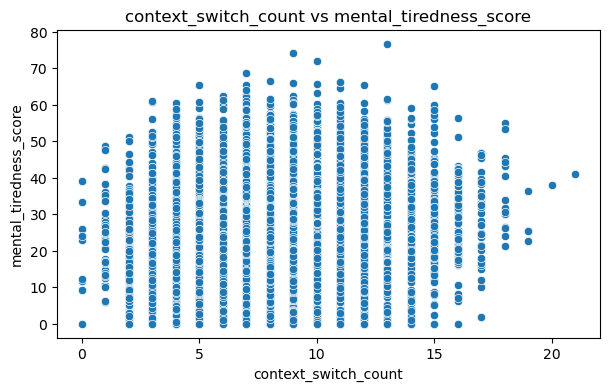

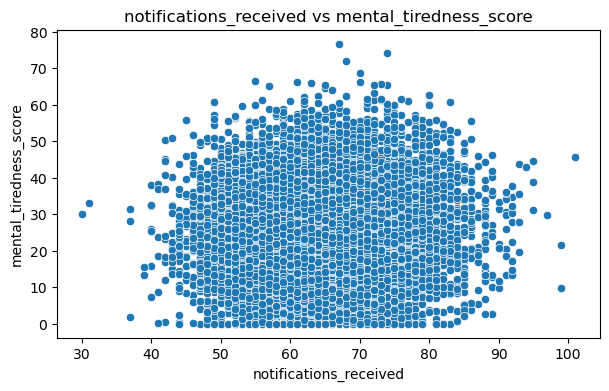

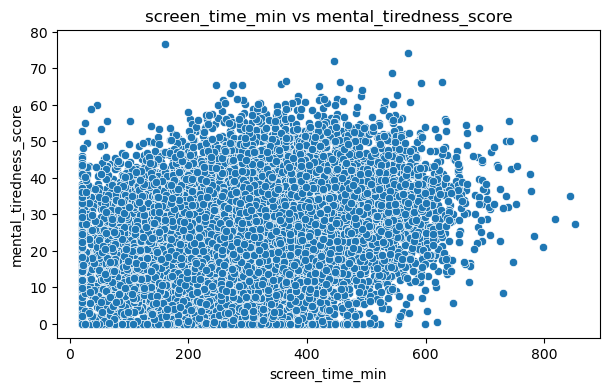

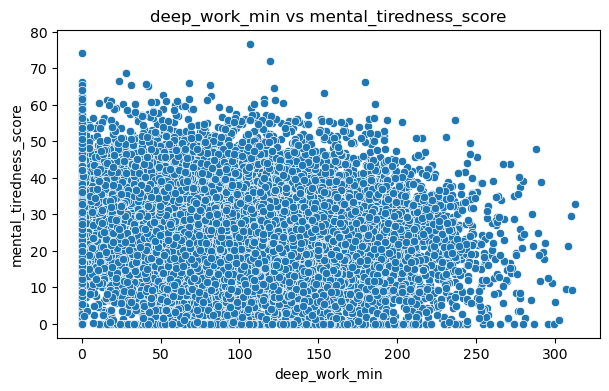

...

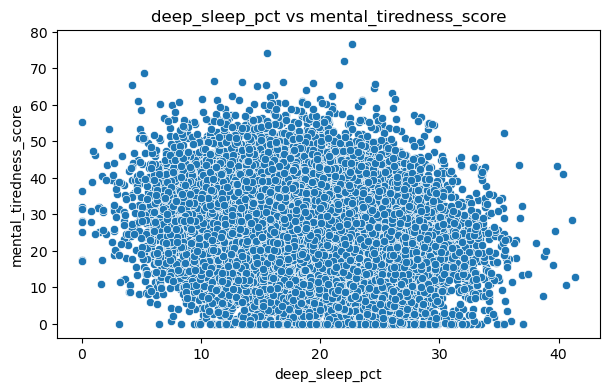

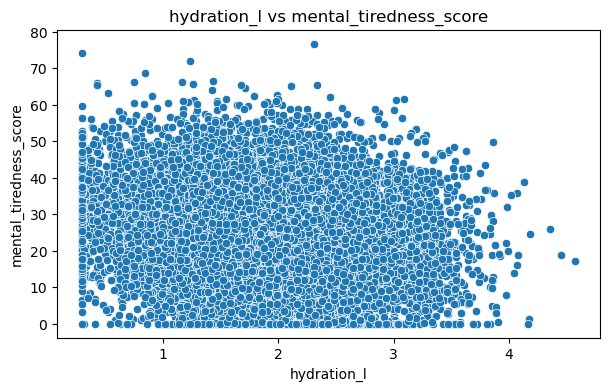

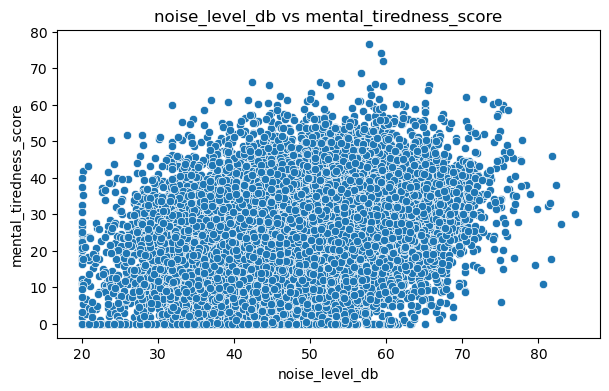

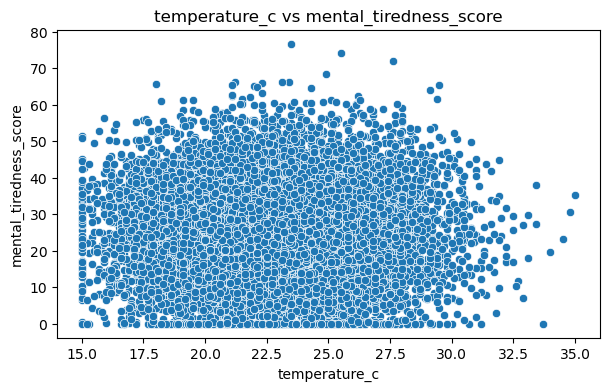

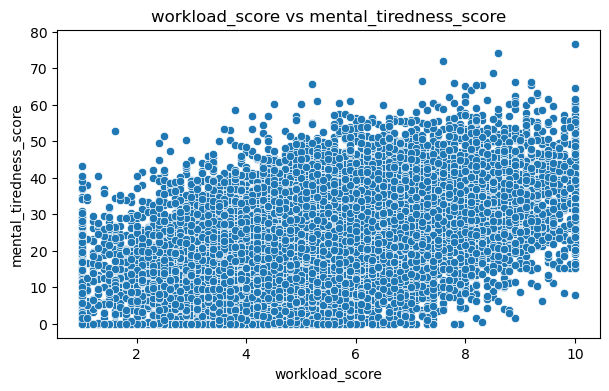

In [47]:
# feature vs target
target = 'mental_tiredness_score'
for col in num_cols:
    if col != target:
        plt.figure(figsize=(7, 4))
        sns.scatterplot(data=df, x=col, y=target)
        plt.title(f'{col} vs {target}')
        plt.show()

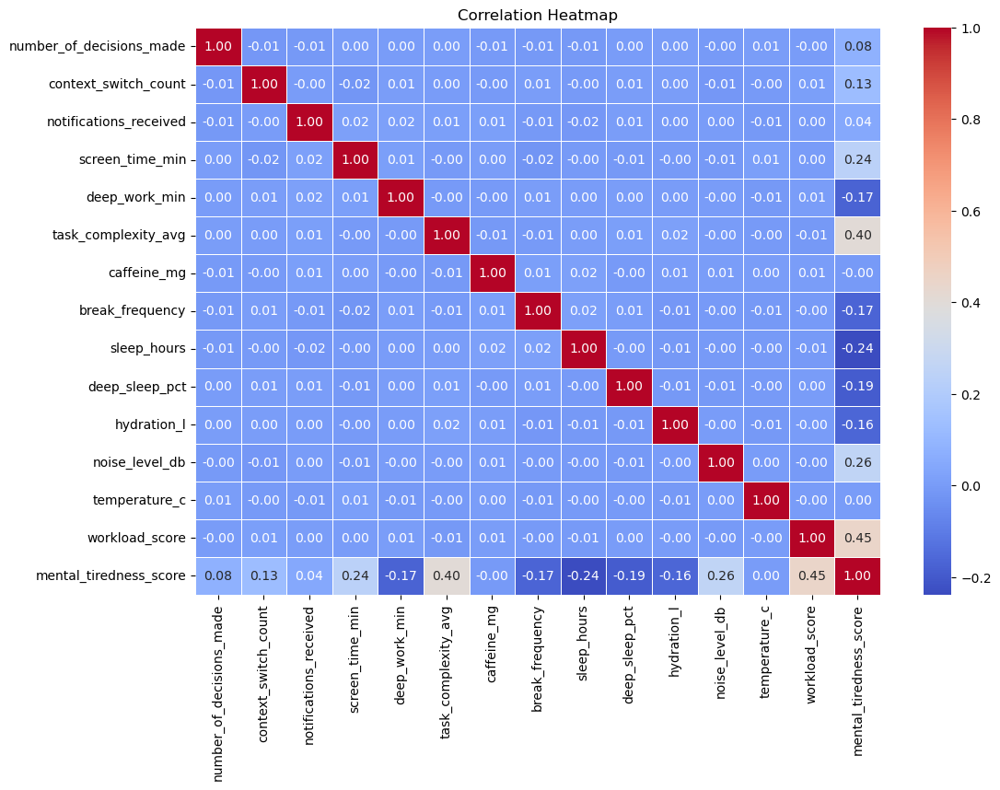

In [51]:
# Correlation Analysis
correlation = df.select_dtypes(
    include="number"
).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()

In [53]:
target_corr = correlation[target].sort_values(ascending=False)

print(target_corr)

mental_tiredness_score      1.000000
workload_score              0.445756
task_complexity_avg         0.403780
noise_level_db              0.258112
screen_time_min             0.236001
context_switch_count        0.126730
number_of_decisions_made    0.078730
notifications_received      0.044155
temperature_c               0.003286
caffeine_mg                -0.002238
hydration_l                -0.161555
break_frequency            -0.168271
deep_work_min              -0.173696
deep_sleep_pct             -0.190308
sleep_hours                -0.238506
Name: mental_tiredness_score, dtype: float64


 #### MultiVariate Analysis

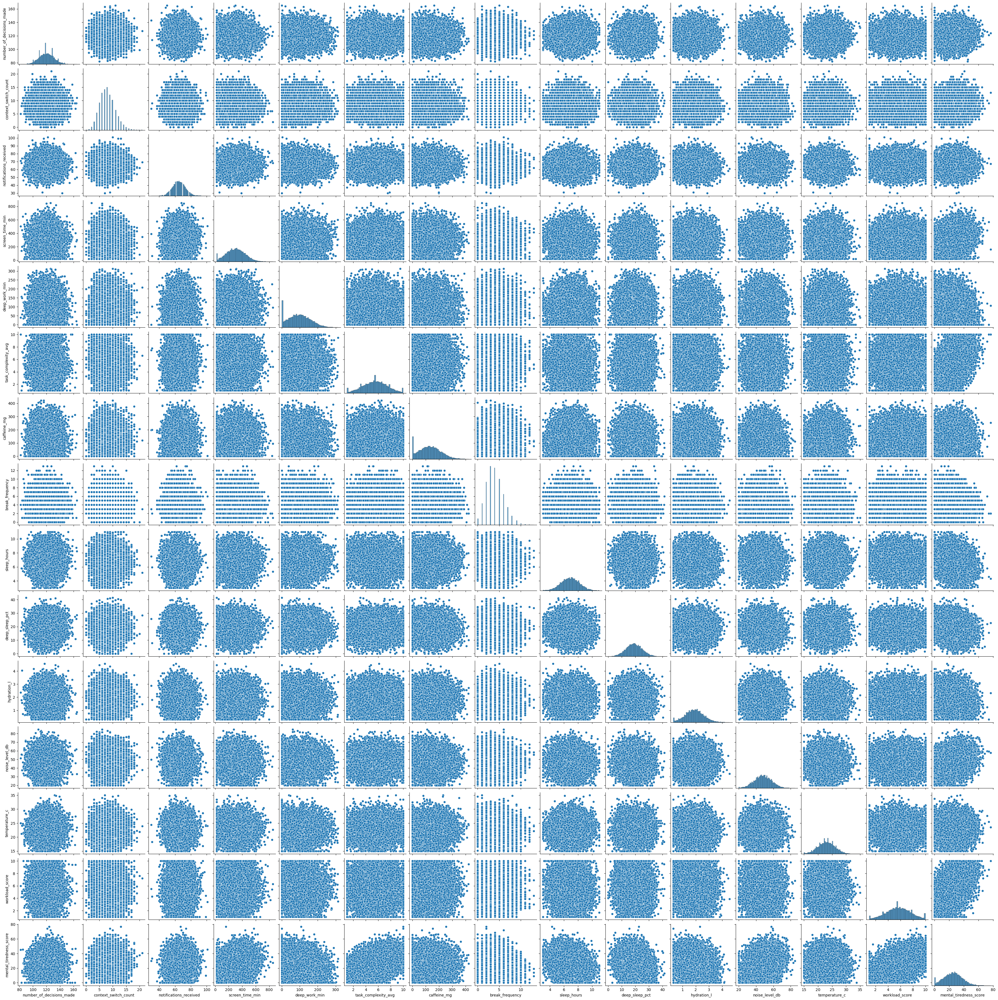

In [55]:
sns.pairplot(df[num_cols])
plt.show()

## Step 5 : Outlier Detection & Treatment

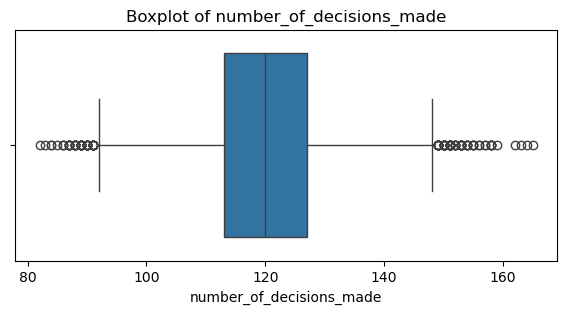

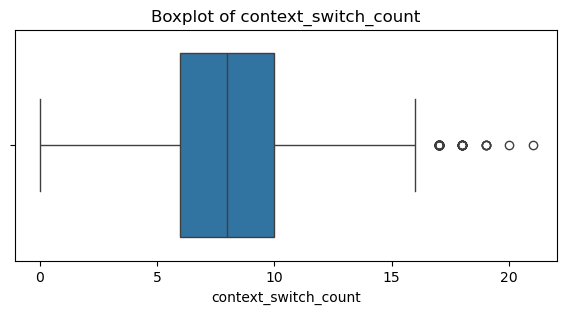

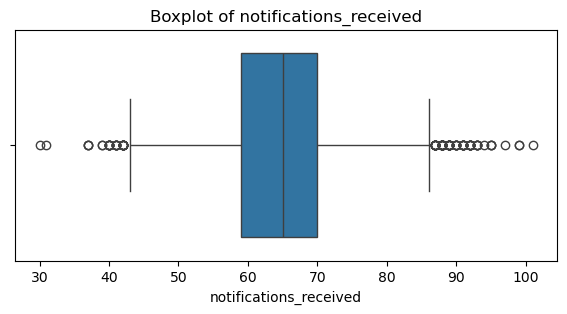

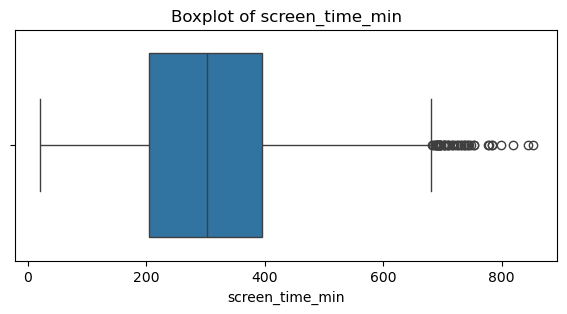

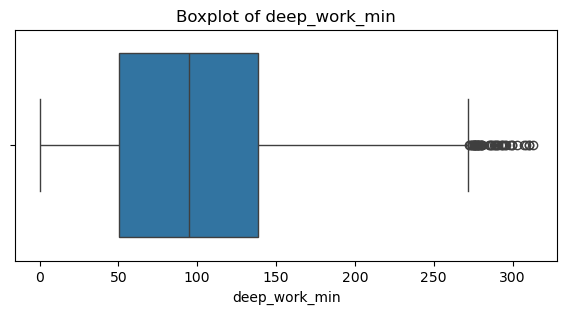

...

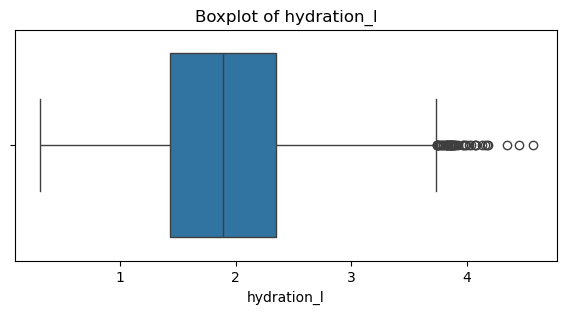

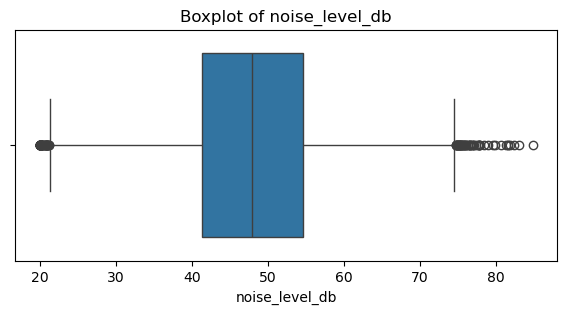

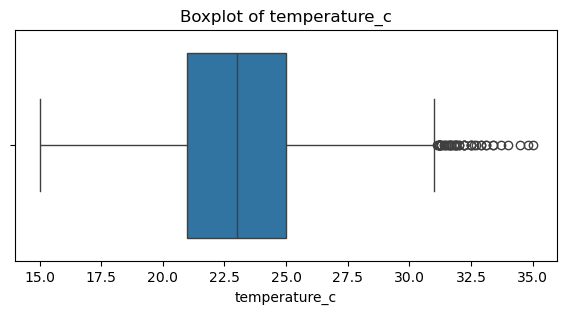

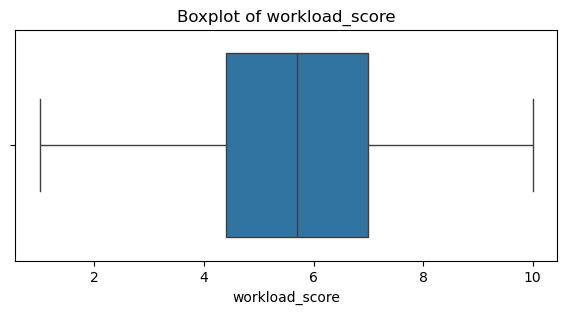

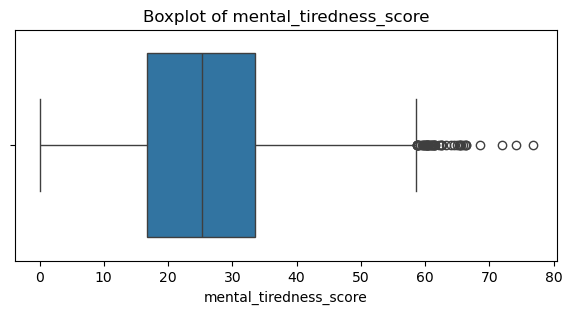

In [96]:
# Boxplots
for col in num_cols:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

####  IQR method

In [61]:

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [63]:
outlier_counts = ((df[num_cols] < lower_bound) |
                  (df[num_cols] > upper_bound)).sum()

print(outlier_counts)

number_of_decisions_made    128
context_switch_count         60
notifications_received      116
screen_time_min              50
deep_work_min                46
task_complexity_avg           0
caffeine_mg                  49
break_frequency             345
sleep_hours                 110
deep_sleep_pct               91
hydration_l                  50
noise_level_db              111
temperature_c                50
workload_score                0
mental_tiredness_score       53
dtype: int64


In [71]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    print(f"{col}:")
    print(f"Lower Bound = {lower:.2f}")
    print(f"Upper Bound = {upper:.2f}")
    print()

number_of_decisions_made:
Lower Bound = 92.00
Upper Bound = 148.00

context_switch_count:
Lower Bound = 0.00
Upper Bound = 16.00

notifications_received:
Lower Bound = 42.50
Upper Bound = 86.50

screen_time_min:
Lower Bound = -80.90
Upper Bound = 682.30

deep_work_min:
Lower Bound = -82.95
Upper Bound = 271.85

task_complexity_avg:
Lower Bound = 0.24
Upper Bound = 10.74

caffeine_mg:
Lower Bound = -97.75
Upper Bound = 355.45

break_frequency:
Lower Bound = 0.00
Upper Bound = 8.00

sleep_hours:
Lower Bound = 3.35
Upper Bound = 10.44

deep_sleep_pct:
Lower Bound = 3.01
Upper Bound = 35.10

hydration_l:
Lower Bound = 0.05
Upper Bound = 3.73

noise_level_db:
Lower Bound = 21.35
Upper Bound = 74.55

temperature_c:
Lower Bound = 15.00
Upper Bound = 31.00

workload_score:
Lower Bound = 0.50
Upper Bound = 10.90

mental_tiredness_score:
Lower Bound = -8.46
Upper Bound = 58.62



In [65]:
for col in num_cols:
    print(f"\n{col}")
    print("Min:", df[col].min())
    print("Max:", df[col].max())


number_of_decisions_made
Min: 82
Max: 165

context_switch_count
Min: 0
Max: 21

notifications_received
Min: 30
Max: 101

screen_time_min
Min: 20.0
Max: 852.2

deep_work_min
Min: 0.0
Max: 312.8

task_complexity_avg
Min: 1.0
Max: 10.0

caffeine_mg
Min: 0.0
Max: 422.9

break_frequency
Min: 0
Max: 13

sleep_hours
Min: 3.0
Max: 11.0

deep_sleep_pct
Min: 0.0
Max: 41.38

hydration_l
Min: 0.3
Max: 4.57

noise_level_db
Min: 20.0
Max: 84.8

temperature_c
Min: 15.0
Max: 35.0

workload_score
Min: 1.0
Max: 10.0

mental_tiredness_score
Min: 0.0
Max: 76.74


In [73]:
# Calculate outlier percentage

outlier_percentage = (
    outlier_counts / len(df) * 100
).sort_values(ascending=False)

print("Outlier percentage for each numerical feature:")
print(outlier_percentage)

Outlier percentage for each numerical feature:
break_frequency             2.300000
number_of_decisions_made    0.853333
notifications_received      0.773333
noise_level_db              0.740000
sleep_hours                 0.733333
deep_sleep_pct              0.606667
context_switch_count        0.400000
mental_tiredness_score      0.353333
screen_time_min             0.333333
hydration_l                 0.333333
temperature_c               0.333333
caffeine_mg                 0.326667
deep_work_min               0.306667
task_complexity_avg         0.000000
workload_score              0.000000
dtype: float64


### Outlier Treatment

IQR-based outlier detection was performed on all numerical variables.

Several variables contained statistical outliers according to the 1.5 × IQR rule. However, the detected values were within plausible domain ranges and were not identified as obvious data-entry errors or impossible values.

Therefore, the detected observations were retained rather than removed or capped. This avoids unnecessarily reducing the dataset and prevents potentially useful information from being discarded.

The target variable `mental_tiredness_score` was also retained without outlier removal because extreme target values may represent legitimate observations.

## Step 6 :  Feature Encoding

In [77]:
target = 'mental_tiredness_score'

X = df.drop(columns=[target])
y = df[target]

In [79]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (15000, 17)
y shape: (15000,)


In [81]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['number_of_decisions_made', 'context_switch_count', 'notifications_received', 'screen_time_min', 'deep_work_min', 'task_complexity_avg', 'caffeine_mg', 'break_frequency', 'sleep_hours', 'deep_sleep_pct', 'hydration_l', 'noise_level_db', 'temperature_c', 'workload_score']

Categorical features:
['mood', 'work_type', 'work_environment']


## Step 7 : Train-Test Split

In [84]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (12000, 17)
X_test: (3000, 17)
y_train: (12000,)
y_test: (3000,)


#### Encoding + Scaling

In [87]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [89]:
# Fit only on Training Data
X_train_processed = preprocessor.fit_transform(X_train)

In [91]:
# Transform the test data
X_test_processed = preprocessor.transform(X_test)

In [93]:
print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (12000, 24)
Processed X_test shape: (3000, 24)
